In [1]:
# Instalar mrmr-selection se não estiver instalado
# !pip install mrmr-selection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score

# Seleção de features mRMR
try:
    from mrmr import mrmr_classif
    MRMR_AVAILABLE = True
except ImportError:
    MRMR_AVAILABLE = False
    print("⚠️ mRMR não está instalado. Instale com: pip install mrmr-selection")

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import VarianceThreshold

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


In [3]:
# Carregar o dataset DoS
dos_path = Path("../data/processed/DoS_with_publish_gap.csv")
df = pd.read_csv(dos_path)

print(f"📊 Shape do dataset: {df.shape}")
print(f"📝 Colunas: {df.shape[1]}")
print(f"📋 Registros: {df.shape[0]}")
print(f"\n🏷️ Distribuição do Label ('type'):")
print(df['type'].value_counts())

📊 Shape do dataset: (94625, 68)
📝 Colunas: 68
📋 Registros: 94625

🏷️ Distribuição do Label ('type'):
type
normal    49111
DoS       45514
Name: count, dtype: int64


In [4]:
# Selecionar apenas features numéricas
num_df = df.select_dtypes(include=['int64', 'float64'])

# Colunas a remover (irrelevantes para detecção de ataques)
colunas_para_remover = [
    'frame.time_delta_displayed', 'frame.time_epoch', 'frame.time_invalid', 
    'frame.time_relative', 'tcp.srcport', 'tcp.dstport', 
    'frame.coloring_rule.name', 'frame.coloring_rule.string', 
    'frame.comment', 'frame.comment.expert', 'frame.encap_type', 
    'frame.file_off', 'frame.ignored', 'frame.incomplete', 
    'frame.interface_id', 'frame.interface_name', 'frame.link_nr', 
    'frame.marked', 'frame.md5_hash', 'frame.number', 'frame.offset_shift',
    'mqtt.msgid', 'mqtt.username', 'mqtt.passwd', 
    'mqtt.willmsg', 'mqtt.willtopic'
]

# Remover colunas existentes no dataframe
colunas_existentes = [c for c in colunas_para_remover if c in num_df.columns]
X = num_df.drop(columns=colunas_existentes, errors='ignore')

# Tratar valores ausentes e infinitos
X = X.fillna(0)
X = X.replace([np.inf, -np.inf], 0)

# Encode do label (target)
le = LabelEncoder()
y = le.fit_transform(df['type'])

print(f"✅ Features numéricas após limpeza: {X.shape[1]}")
print(f"🎯 Classes: {le.classes_}")
print(f"📊 Shape X: {X.shape}, y: {y.shape}")

✅ Features numéricas após limpeza: 30
🎯 Classes: ['DoS' 'normal']
📊 Shape X: (94625, 30), y: (94625,)


In [6]:
X.describe()

,frame.time_delta,frame.cap_len,frame.len,mqtt.clientid_len,mqtt.conack.flags.reserved,mqtt.conack.flags.sp,mqtt.conack.val,mqtt.conflag.cleansess,mqtt.conflag.passwd,mqtt.conflag.qos,mqtt.conflag.reserved,mqtt.conflag.retain,mqtt.conflag.uname,mqtt.conflag.willflag,mqtt.dupflag,mqtt.kalive,mqtt.len,mqtt.msgtype,mqtt.passwd_len,mqtt.proto_len,mqtt.qos,mqtt.retain,mqtt.sub.qos,mqtt.suback.qos,mqtt.topic_len,mqtt.username_len,mqtt.ver,mqtt.willmsg_len,mqtt.willtopic_len,publish_gap
count,94625.000000,94625.000000,94625.000000,94625.000000,94625.000000,94625.000000,94625.000000,94625.000000,94625.0,94625.0,94625.0,94625.0,94625.0,94625.0,94625.000000,94625.000000,94625.000000,94625.000000,94625.0,94625.000000,94625.000000,94625.000000,94625.0,94625.0,94625.000000,94625.0,94625.000000,94625.0,94625.0,94625.000000
mean,0.012070,972.513828,972.513828,0.124756,0.004713,0.003065,0.403445,0.003413,0.0,0.0,0.0,0.0,0.0,0.0,0.001987,0.197675,65.932639,1.299741,0.0,0.013654,0.012026,0.004196,0.0,0.0,166.283477,0.0,0.013654,0.0,0.0,4.097958
std,0.144073,663.725442,663.725442,2.144253,0.068492,0.055275,6.170456,0.058325,0.0,0.0,0.0,0.0,0.0,0.0,0.044529,3.422652,80.146643,1.689624,0.0,0.233302,0.171537,0.064637,0.0,0.0,1614.081359,0.0,0.233302,0.0,0.0,10.853330
min,0.000000,38.000000,38.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000
25%,0.000062,77.000000,77.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000
50%,0.000130,1514.000000,1514.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.194238
75%,0.000781,1514.000000,1514.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,163.000000,3.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,63.000000,0.0,0.000000,0.0,0.0,2.425834
max,5.628732,1514.000000,1514.000000,38.000000,1.000000,1.000000,116.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,60.000000,182.000000,14.000000,0.0,4.000000,3.000000,1.000000,0.0,0.0,29044.000000,0.0,4.000000,0.0,0.0,57.168259


In [7]:
if MRMR_AVAILABLE:
    K = 15 

x_mrmr = X.copy()
y_series = pd.Series(y, name ='target')

print(f"Executando mRMR para selecionar {K} features")

#Retornar a lista de features em ordem de importância 
selected_features = mrmr_classif(X=x_mrmr, y=y_series, K=K)

print(f" Top {K} Features por mRMR com o novo dataset:")
for i, feature in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feature}")


Executando mRMR para selecionar 15 features


100%|██████████| 15/15 [00:03<00:00,  4.32it/s]

 Top 15 Features por mRMR com o novo dataset:
   1. mqtt.len
   2. mqtt.dupflag
   3. mqtt.msgtype
   4. publish_gap
   5. frame.cap_len
   6. frame.len
   7. mqtt.kalive
   8. mqtt.topic_len
   9. frame.time_delta
  10. mqtt.qos
  11. mqtt.clientid_len
  12. mqtt.retain
  13. mqtt.conack.flags.reserved
  14. mqtt.conflag.cleansess
  15. mqtt.conack.val


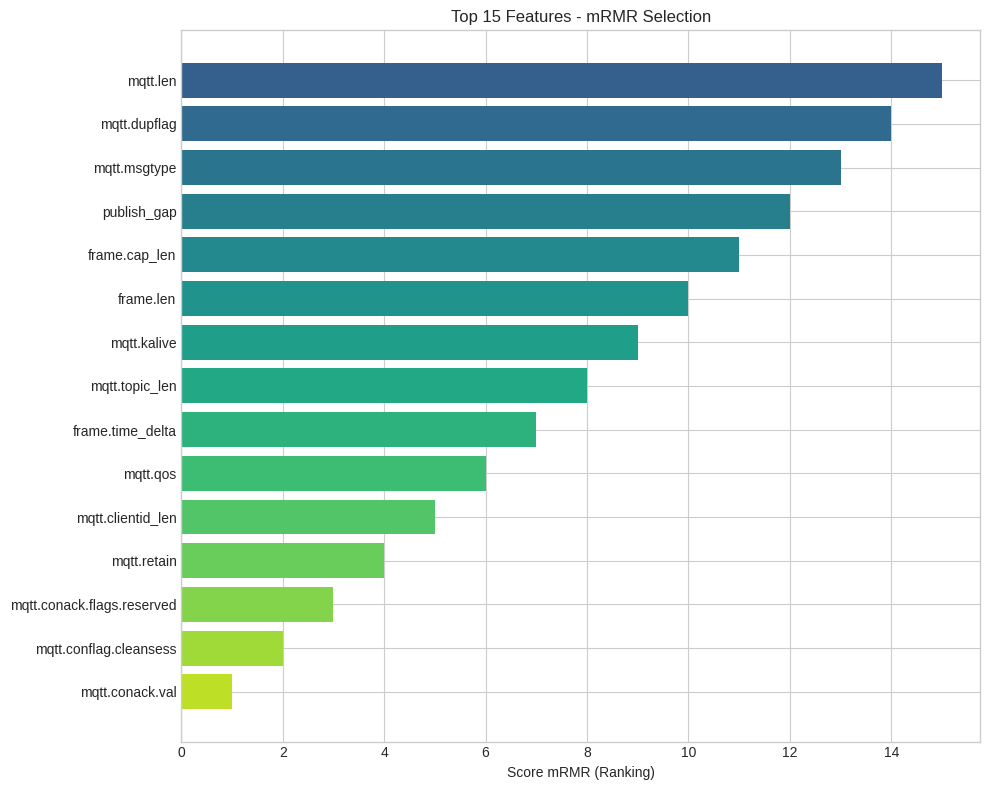

In [9]:
if selected_features:
    #Criar dataframe com ranking
    mrmr_ranking = pd.DataFrame({
        'rank': range(1, len(selected_features) + 1),
        'feature': selected_features
    })

#Plotar ranking
    fig, ax = plt.subplots(figsize=(10,8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(selected_features)))
    
    bars = ax.barh(range(len(selected_features)), 
                   range(len(selected_features), 0, -1),
                   color=colors)
    
    ax.set_yticks(range(len(selected_features)))
    ax.set_yticklabels(selected_features)
    ax.set_xlabel('Score mRMR (Ranking)')
    ax.set_title(f'Top {len(selected_features)} Features - mRMR Selection', fontsize=12)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()